In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import sys
import scipy.linalg as lng
import scipy.io as io
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from tabulate import tabulate
from sklearn.model_selection import GridSearchCV

## 2. Data Preprocessing

Download dataset again, to make sure there are no mistakes

In [16]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

Replace NaN values in numerical features by their median

In [17]:
numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64


Remove categorical feature C_02 since it presents the same value for all rows (72 and NaN)

In [18]:
categorical_data.drop(columns="C_02", inplace=True)

Replace NaN values in categorical features by a new categorical value "missing"

In [19]:
categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64


One-hot encode categorical data

In [20]:
categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

,C_01_71.0,C_01_72.0,C_01_73.0,C_01_74.0,C_01_75.0,C_01_missing,C_03_71.0,C_03_72.0,C_03_73.0,C_03_74.0,...,C_04_73.0,C_04_74.0,C_04_75.0,C_04_missing,C_05_71.0,C_05_72.0,C_05_73.0,C_05_74.0,C_05_75.0,C_05_missing
0,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


Rename columns to remove .0 from their names

In [21]:
categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

,C_01_71,C_01_72,C_01_73,C_01_74,C_01_75,C_01_missing,C_03_71,C_03_72,C_03_73,C_03_74,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


Join numerical and categorical features

In [22]:
X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


## 3. Random Forest approach

First we set the hyperparameters, keeping in mind we're using RF on a regression problem.

In [ ]:
# Hyperparameters
seed = 42

# Obtain number of input parameters:
# Note: We reduce the amount of parameters by 30,
# since we have one-hot encoded the categorical entries.
# As per the recommended default value for m, we intially divide p by 3 to get m.
p = X.shape[1]-30
m = np.floor(p/3)
print("m ist set to:", m)


m ist set to: 29.0


Intialize the Random Forest:

In [36]:
# Try to experiment with criterion, number of estimators, max_depth, min_samples_leaf
rf = RandomForestRegressor(bootstrap=True, oob_score=True, criterion = 'squared_error', random_state = seed)

Perform a tree feature grid-search for optimal parameters:

In [38]:
# number of trees
n_estimators = range(5,101)
max_depth = range(1,11)
max_features = range(10,250,20)

# Try to add more of the parameters from the model and then add them to this dict to see how it affects the model.
param_grid = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'max_features': max_features
}

rf_grid = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, verbose=2, n_jobs=-1)

# Fit the grid search model
rf_grid.fit(X, y_class)

#Save the results in a dataframe to disk
df = pd.DataFrame(rf_grid.cv_results_)
df.to_csv('CrossValidationResultsRandomForest.csv')

print(rf_grid.best_estimator_)

Fitting 5 folds for each of 11520 candidates, totalling 57600 fits


c:\Users\esbya\projects\cda_02582\cda_env\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


RandomForestRegressor(max_depth=9, max_features=70, n_estimators=8,
                      oob_score=True, random_state=42)


Graphing the error as a function of n_estimators:

Text(0, 0.5, 'Mean test accuracy')

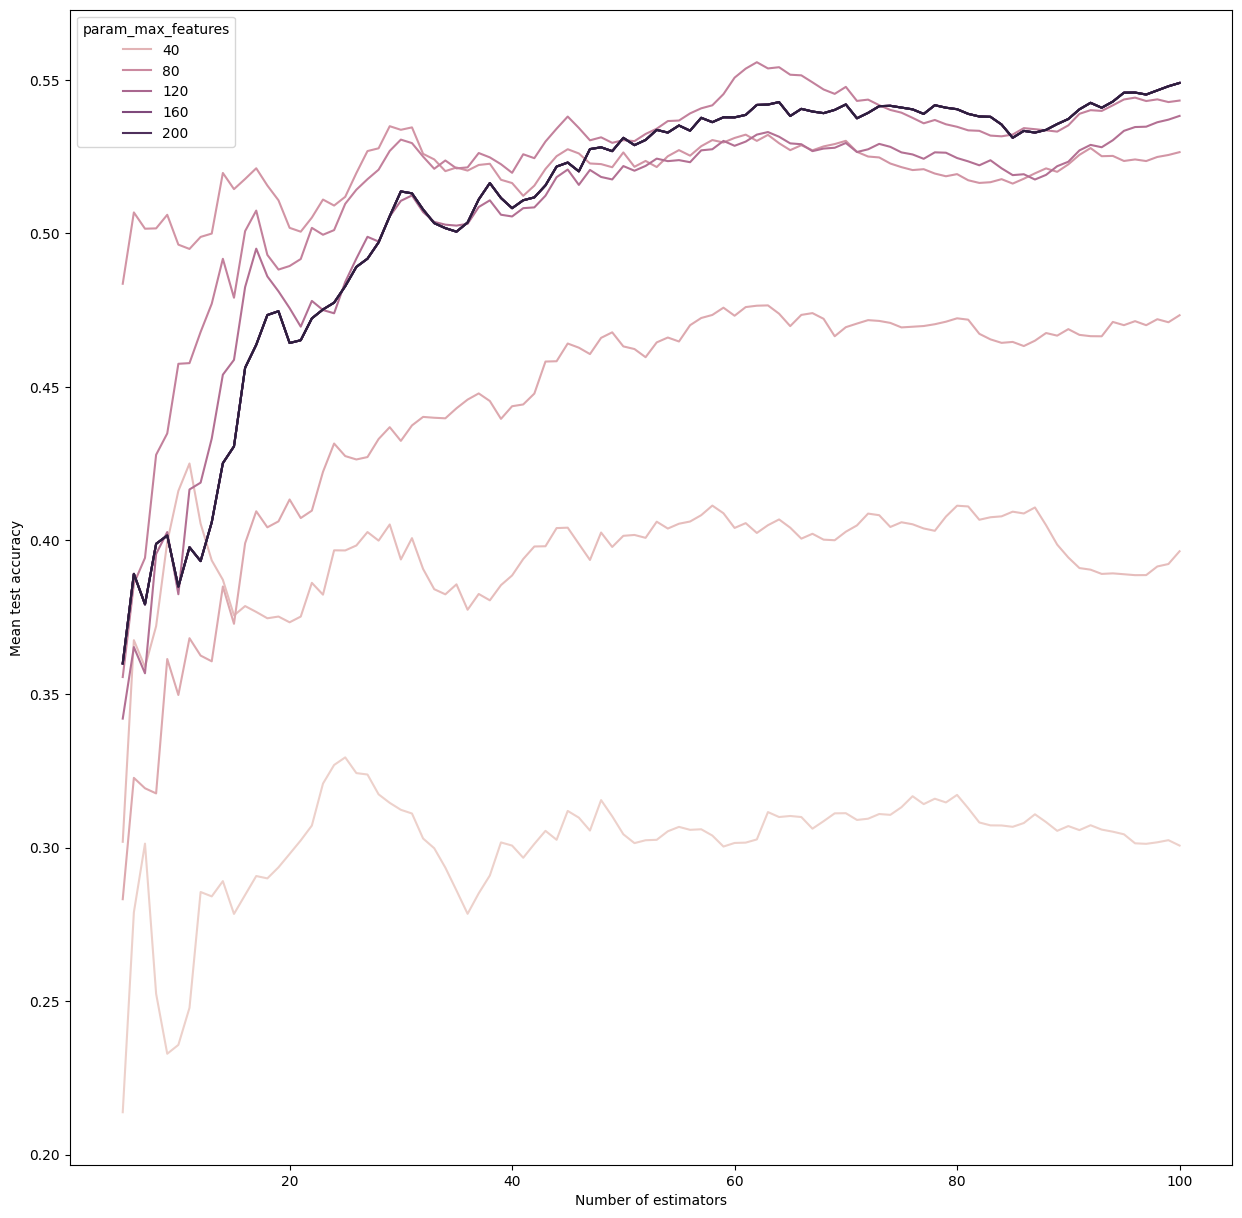

In [39]:
df_100_estimators = df[df['param_max_depth']==10]

fig, ax = plt.subplots(figsize=(15,15))

_ = sns.lineplot(data=df_100_estimators, x='param_n_estimators', y='mean_test_score', hue='param_max_features', ax=ax)
ax.set_xlabel('Number of estimators')
ax.set_ylabel('Mean test accuracy')

Graphing the error as a function of max depth:

n_estimators fixed at variable m, the expected best default.

Text(0, 0.5, 'Mean test accuracy')

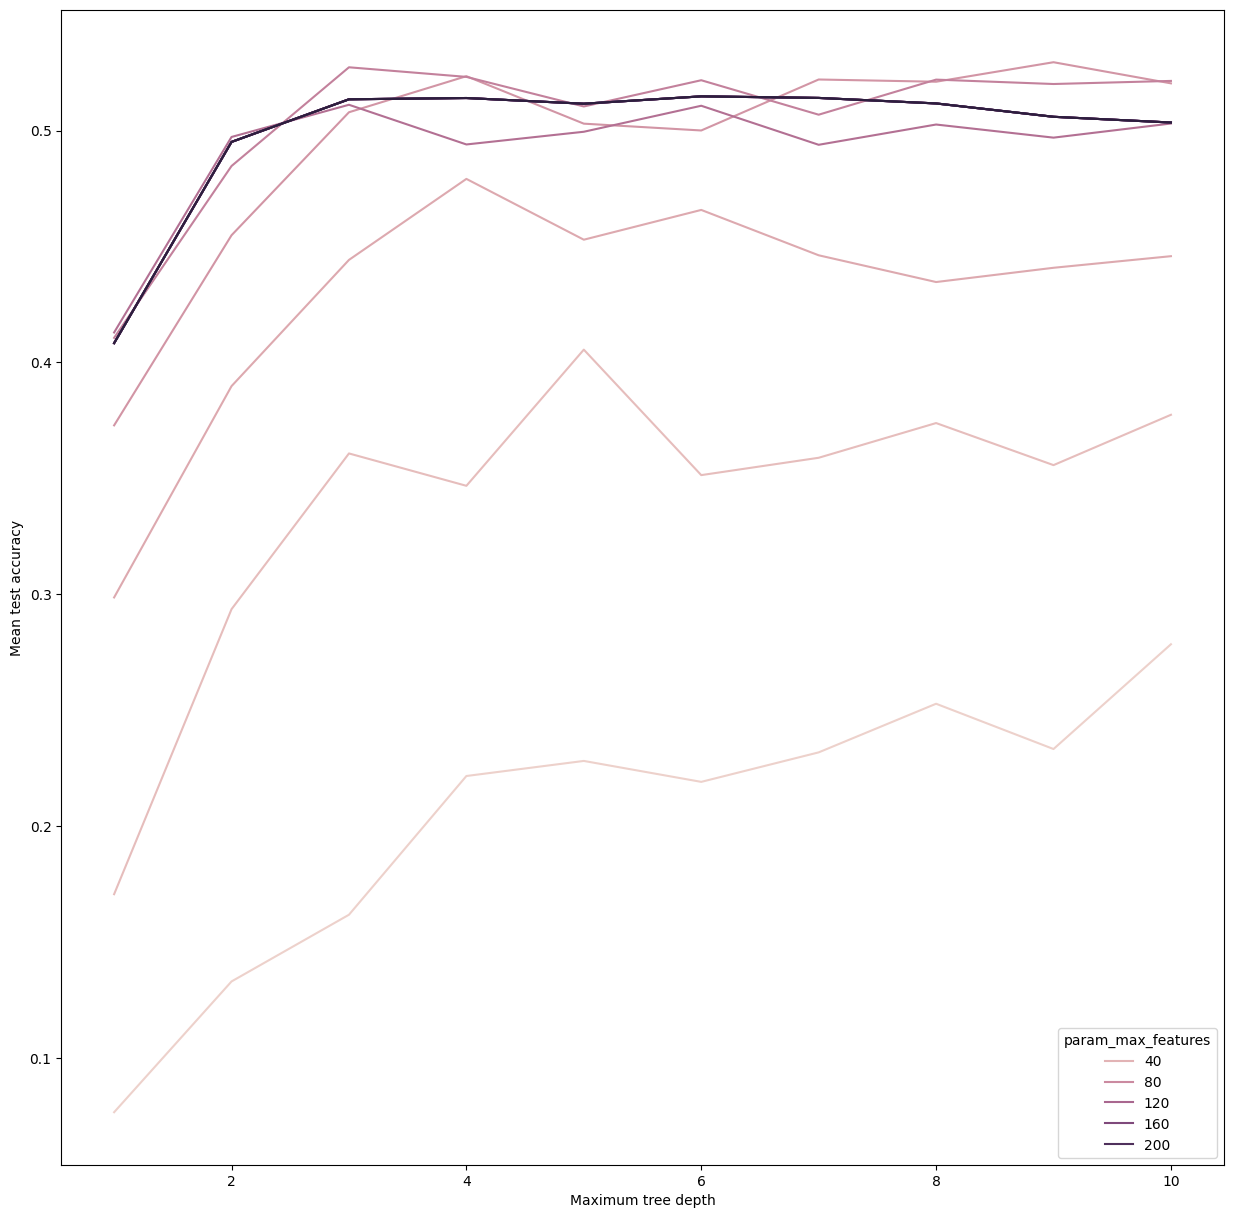

In [41]:
df_100_estimators = df[df['param_n_estimators'] == 36]

fig, ax = plt.subplots(figsize=(15,15))

_ = sns.lineplot(data=df_100_estimators, x='param_max_depth', y='mean_test_score', hue='param_max_features', ax=ax)
ax.set_xlabel('Maximum tree depth')
ax.set_ylabel('Mean test accuracy')

Text(0, 0.5, 'Mean test accuracy')

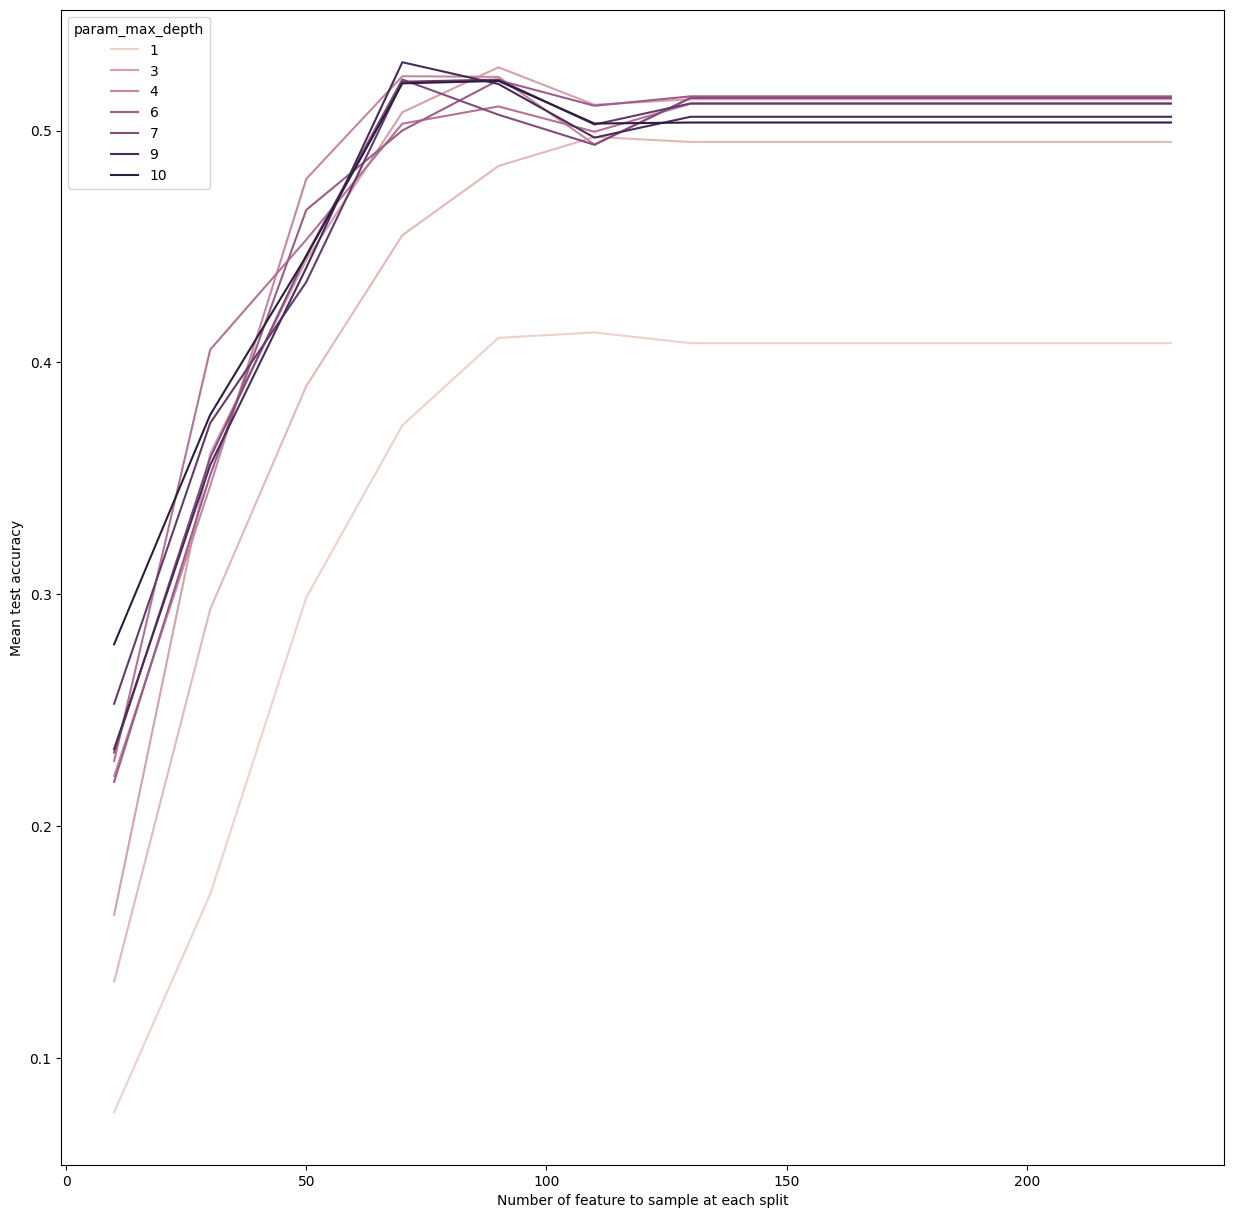

In [42]:
fig, ax = plt.subplots(figsize=(15,15))

_ = sns.lineplot(data=df_100_estimators, x='param_max_features', y='mean_test_score', hue='param_max_depth', ax=ax)
ax.set_xlabel('Number of feature to sample at each split')
ax.set_ylabel('Mean test accuracy')

In [44]:
## Look at the best estimator and the importance of the features
score = rf_grid.best_estimator_.fit(X, y_class)
headers = ["name", "score"]
values = sorted(zip(range(0,p), rf_grid.best_estimator_.feature_importances_), key=lambda x: x[1] * -1)

# See which features are deemed most important by the classifier
# Only gonna look at the 10 most important features
print(tabulate(values[0:10], ["name", "score"][0:10], tablefmt="plain"))
print ('Random Forest OOB error rate: {}'.format(1 - rf_grid.best_estimator_.oob_score_))

  name      score
    31  0.328257
    35  0.143193
    30  0.0473453
    21  0.0354785
    61  0.0319248
    56  0.0273289
    25  0.0227824
    34  0.0206671
    22  0.02063
    24  0.0179978
Random Forest OOB error rate: 0.9990450395797229


c:\Users\esbya\projects\cda_02582\cda_env\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Variable importance plots:

Proximity plots?